# Lecture: Optical Character Recognition (OCR) with MNIST and Safran-MNIST-DLS dataset
**Author:** *Florent Imbert*  
**Course:** Project in Industrial AI   
**Date:** November 2025  


# Introduction

Optical Character Recognition (OCR) is one of the most established applications of Artificial Intelligence in the industrial and research domains.  
It refers to the process of **automatically detecting and interpreting textual symbols from images**, enabling the conversion of scanned documents, photographs, or handwritten notes into machine-readable text.

In industrial contexts, OCR serves as a critical technology in:
- **Document digitization** and automated form processing  
- **Quality control** (e.g., serial number recognition on components)  
- **Logistics and manufacturing** (label and barcode reading)  
- **Banking and administration** (cheque and ID recognition)  

From a deep learning perspective, OCR is typically formulated as a **supervised image classification** or **sequence-to-sequence recognition** problem, depending on the task’s complexity.  
For handwritten digit recognition, we rely on convolutional neural networks (CNNs) to learn spatial hierarchies of visual patterns, providing robust generalization to unseen samples.

## MNIST Dataset Overview

The **MNIST dataset** (Modified National Institute of Standards and Technology) is one of the most widely used benchmarks in computer vision and OCR.  
It contains **70,000 grayscale images** of handwritten digits (0–9), each of size **28×28 pixels**, divided into:
- 60,000 training samples  
- 10,000 test samples  

Each image is centered and size-normalized, providing a simple yet powerful benchmark for pattern recognition and neural network experimentation.

### Key properties:
- **Input shape:** 1 × 28 × 28  
- **Output classes:** 10 digits (0–9)  
- **Format:** Grayscale intensity values normalized to [0, 1] or [-1, 1]  
- **Challenge:** Inter-class similarity (e.g., ‘3’ vs ‘5’) and intra-class variability (different handwriting styles)

Despite its simplicity, MNIST remains pedagogically valuable for introducing:
- Image preprocessing and normalization  
- CNN architecture design
- Overfitting control via regularization  
- Evaluation through accuracy and confusion matrices  

## Learning Objectives

By the end of this lecture, students will be able to:
<ul>
  <li>Explain the fundamentals of OCR and its industrial applications.  
  <li>Describe the structure and statistical properties of the MNIST dataset.  
  <li>Design, train, and evaluate a convolutional neural network for digit classification.  
  <li>Interpret model errors and visualize learned representations.  
  <li>Extend the OCR framework to more complex or domain-specific datasets.
<ul>

# Section 1: First example on MNIST

In [ ]:
#@title <h2>Part 1: Setup and Importing Libraries</h2>
#@markdown <p>First, we need to import the necessary tools. We'll use <strong>PyTorch</strong> for building and training our model. We'll also use <strong>torchvision</strong> to easily load the MNIST dataset and apply transformations. <strong>Matplotlib</strong> will be used for visualizing our data.</p>

import torch
import torch.nn as nn  # All the neural network modules
import torch.nn.functional as F  # Contains activation functions like ReLU
import torch.optim as optim  # Contains optimizers like Adam
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch Version: {torch.__version__}")

# Check for GPU and set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PyTorch Version: 2.8.0+cu126
Using device: cpu


In [ ]:
#@title <h2>Part 2: Load and Prepare the Dataset</h2>
#@markdown <p>In PyTorch, we use <code>torchvision.transforms</code> to define a pipeline of preprocessing steps. We will then load the data with <code>torchvision.datasets.MNIST</code> and wrap it in a <code>DataLoader</code>, which handles batching and shuffling for us.</p>
#@markdown
#@markdown <h4>Transforms:</h4>
#@markdown <ol>
#@markdown     <li><strong><code>transforms.ToTensor()</code>:</strong> Converts the images from a PIL Image format to a PyTorch Tensor. It also scales the pixel values from [0, 255] to [0.0, 1.0].</li>
#@markdown     <li><strong><code>transforms.Normalize()</code>:</strong> Normalizes the tensor image with a given mean and standard deviation. This helps the network train more stably. For MNIST, the mean is 0.1307 and std dev is 0.3081 (these are pre-computed values for the dataset).</li>
#@markdown </ol>

# Define the transformation pipeline
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download and load the training data
train_dataset = datasets.MNIST(
    root='./data',  # Directory to save the data
    train=True,
    download=True,
    transform=transform
)

# Download and load the test data
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Define batch size
batch_size = 128

# Create the DataLoaders
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True  # Shuffle the training data every epoch
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False # No need to shuffle test data
)

print(f"Loaded {len(train_dataset)} training images in {len(train_loader)} batches.")
print(f"Loaded {len(test_dataset)} test images in {len(test_loader)} batches.")

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 496kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.63MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]

Loaded 60000 training images in 469 batches.
Loaded 10000 test images in 79 batches.


Image batch shape: torch.Size([128, 1, 28, 28])
Label batch shape: torch.Size([128])


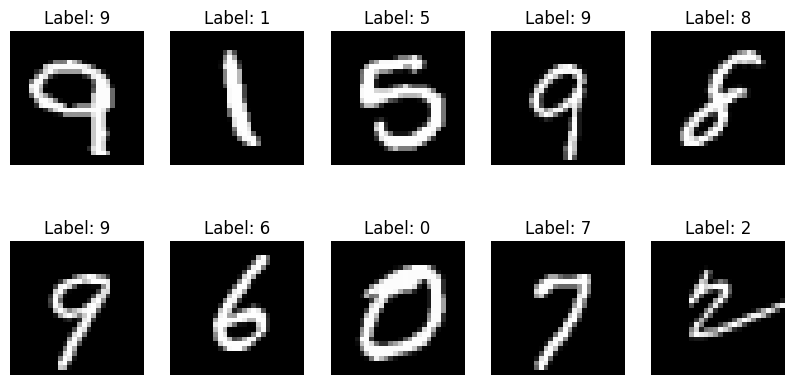

In [ ]:
#@title <h3>Part 3: Visualizing the Data</h3>
#@markdown <p>Let's look at a few of the digits we'll be training on. This is always a good step to make sure your data loaded correctly.</p>

# Get one batch of training images
data_iter = iter(train_loader)
images, labels = next(data_iter)

print(f"Image batch shape: {images.shape}")
print(f"Label batch shape: {labels.shape}")

plt.figure(figsize=(10, 5))
for i in range(10):  # Show the first 10 images in the batch
    plt.subplot(2, 5, i + 1)
    # We use .squeeze() to remove the channel dimension (1, 28, 28) -> (28, 28)
    # We use .numpy() to convert the tensor to a numpy array for matplotlib
    plt.imshow(images[i].squeeze().numpy(), cmap='gray')
    plt.title(f"Label: {labels[i].item()}")
    plt.axis('off')
plt.show()

In [ ]:
#@title <h2>Part 4: Building the OCR Model</h2>
#@markdown <p>Let's start with a custom simple CNN</p>

# Define a simple CNN architecture
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        # Input: 1 x 28 x 28
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)   # -> 32 x 28 x 28
        self.pool1 = nn.MaxPool2d(2, 2)                           # -> 32 x 14 x 14
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # -> 64 x 14 x 14
        self.pool2 = nn.MaxPool2d(2, 2)                           # -> 64 x 7 x 7
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# Initialize and move model to device
model = SimpleCNN(num_classes=10).to(device)

print(model)


SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [ ]:
#@title <h2>Part 5: Define Loss, Optimizer, and Training Loop</h2>
#@markdown <p>This is a key part of working with PyTorch. Unlike Keras, we write the training and testing loops ourselves. This gives us complete control.</p>
#@markdown
#@markdown <ul>
#@markdown     <li><strong>Loss Function:</strong> <code>nn.NLLLoss()</code> (Negative Log Likelihood Loss). This is the standard loss to use with <code>log_softmax</code>.</li>
#@markdown     <li><strong>Optimizer:</strong> <code>optim.Adam</code>. A very effective and popular default optimizer. We tell it what parameters to optimize (<code>model.parameters()</code>).</li>
#@markdown </ul>

# Define the loss function
criterion = nn.CrossEntropyLoss()

# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

#@markdown <h3>Training Function</h3>
#@markdown <p>This function defines one full pass (epoch) over the training data.</p>

from tqdm.auto import tqdm

def train(model, device, train_loader, optimizer, epoch):
    model.train()  # Set the model to training mode (enables dropout)
    train_loss = 0
    # Wrap the train_loader with tqdm for a progress bar
    for batch_idx, (data, target) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch} Training", leave=False)):
        # Move data and labels to the device
        data, target = data.to(device), target.to(device)

        # 1. Zero the gradients
        optimizer.zero_grad()

        # 2. Perform a forward pass
        output = model(data)

        # 3. Calculate the loss
        loss = criterion(output, target)

        # 4. Perform a backward pass (calculate gradients)
        loss.backward()

        # 5. Update the weights
        optimizer.step()

        train_loss += loss.item()

    # Print average loss for the epoch
    avg_loss = train_loss / len(train_loader.dataset)
    print(f'Epoch: {epoch} \tTraining Loss: {avg_loss:.6f}')
    return avg_loss

#@markdown <h3>Test (Evaluation) Function</h3>
#@markdown <p>This function evaluates the model on the test dataset.</p>

def test(model, device, test_loader):
    model.eval()  # Set the model to evaluation mode (disables dropout)
    test_loss = 0
    correct = 0

    with torch.no_grad():  # Disable gradient calculation
        # Wrap the test_loader with tqdm for a progress bar
        for data, target in tqdm(test_loader, desc="Testing", leave=False):
            data, target = data.to(device), target.to(device)
            output = model(data)

            # Sum up batch loss
            test_loss += criterion(output, target).item()

            # Get the index of the max log-probability (the prediction)
            pred = output.argmax(dim=1, keepdim=True)

            # Check if the prediction is correct
            correct += pred.eq(target.view_as(pred)).sum().item()

    # Calculate average loss and accuracy
    test_loss /= len(test_loader.dataset)
    accuracy = 100. * correct / len(test_loader.dataset)

    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({accuracy:.2f}%)\n')
    return test_loss, accuracy

In [ ]:
#@title <h2>Part 6: Training and Evaluating the Model</h2>
#@markdown <p>Now we just need to loop for a few epochs and call our <code>train</code> and <code>test</code> functions!</p>
#@markdown <p>An accuracy of > 99% is excellent for this task!</p>

epochs = 100
train_losses = []
test_losses = []
test_accuracies = []

print("Starting training...")

for epoch in range(1, epochs + 1):
    train_loss = train(model, device, train_loader, optimizer, epoch)
    test_loss, accuracy = test(model, device, test_loader)

    # Save metrics for plotting
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    test_accuracies.append(accuracy)

print("Training finished!")

Starting training...


Epoch 1 Training:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 1 	Training Loss: 0.001607


Testing:   0%|          | 0/79 [00:00<?, ?it/s]


Test set: Average loss: 0.0005, Accuracy: 9820/10000 (98.20%)



...


Test set: Average loss: 0.0004, Accuracy: 9942/10000 (99.42%)



Epoch 100 Training:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 100 	Training Loss: 0.000020


Testing:   0%|          | 0/79 [00:00<?, ?it/s]


Test set: Average loss: 0.0005, Accuracy: 9934/10000 (99.34%)

Training finished!


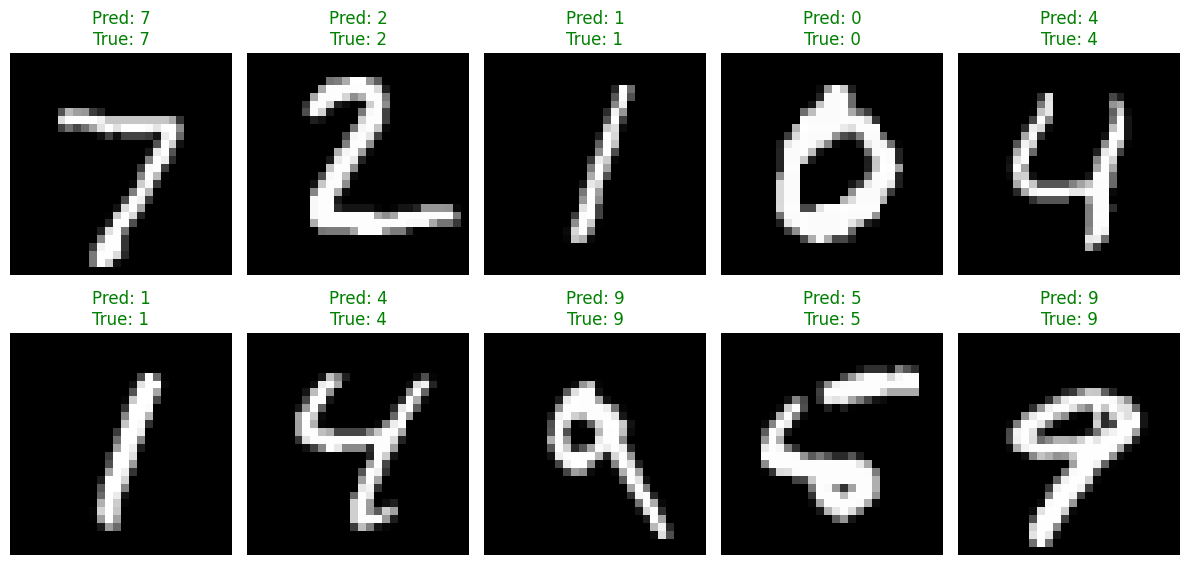

In [ ]:
#@title <h2>Part 7: Testing the Model on Single Images</h2>
#@markdown <p>The final and most fun part. Let's grab some images from our test set, feed them to the model, and see what it predicts!</p>

# Get a batch of test data
data_iter = iter(test_loader)
images, labels = next(data_iter)

# Move data to the device
images_gpu = images.to(device)
labels_gpu = labels.to(device)

# Get predictions
with torch.no_grad():
    output = model(images_gpu)

# Get the predictions by finding the class with the highest log-probability
preds = output.argmax(dim=1)

# Move data back to CPU for plotting with numpy/matplotlib
images_cpu = images.cpu()
labels_cpu = labels.cpu()
preds_cpu = preds.cpu()


# Show the first 10 test images, their predicted labels, and the true labels
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)

    # Show the image (squeeze to remove channel dim)
    plt.imshow(images_cpu[i].squeeze(), cmap='gray')

    predicted_label = preds_cpu[i].item()
    true_label = labels_cpu[i].item()

    # Set title color
    color = 'green' if predicted_label == true_label else 'red'

    plt.title(f"Pred: {predicted_label}\nTrue: {true_label}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

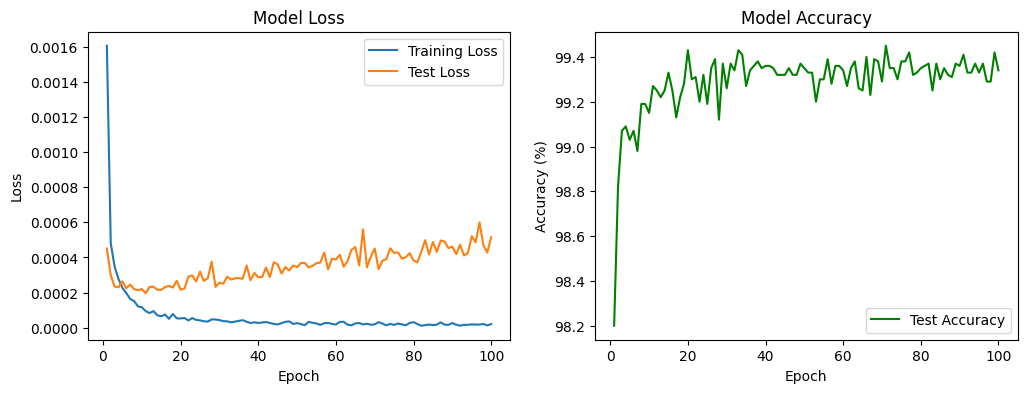

In [ ]:
#@title <h2>Part 8: Plotting Training History</h2>
#@markdown <p>We can now plot the model's accuracy and loss over the epochs. This helps us see if the model is still improving or if it has started to "overfit."</p>

plt.figure(figsize=(12, 4))

# Plot training, validation, and test loss
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss')
plt.plot(range(1, len(test_losses) + 1), test_losses, label='Test Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot validation and test accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(test_accuracies) + 1), test_accuracies, label='Test Accuracy', color='green')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.show()

# Section 2: Questions analyze and futur improvment

## Question for Students

Considering the experimental setup used in this notebook (dataset, model, transformations, optimizer, etc.), what aspects do you think are most important for achieving high accuracy on the MNIST dataset?
*   **Dataset:**
*   **Model:**
*   **Transformations:**
*   **Optimizer and Loss Function:**
*   **Device:**

## Question for Students

Based on the training and test loss and accuracy plots, what can you conclude about the model's performance and whether it is overfitting or underfitting on the MNIST dataset? Explain your reasoning based on the behavior of the curves.

## Question for Students

Based on your understanding of this notebook and the principles of deep learning for image recognition, propose a new experimental setup (including dataset, model architecture, transformations, optimizer, etc.) that you believe would further improve the results on the MNIST dataset or a similar OCR task. Justify your choices.

# Section 3: Best practice for MNIST dataset

In [ ]:
#@title <h2>Part 1: Modify data loading</h2>
# <p>Split the training dataset into training and validation sets.<p>
# Calculate the size of the training and validation sets
train_size = int(0.6 * len(train_dataset))
val_size = len(train_dataset) - train_size

# Split the original training dataset into new training and validation datasets
train_dataset, val_dataset = torch.utils.data.random_split(
    train_dataset, [train_size, val_size]
)

# Create a DataLoader for the validation set
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    shuffle=False  # No need to shuffle validation data
)

print(f"Split training data into {len(train_dataset)} training images and {len(val_dataset)} validation images.")
print(f"Loaded {len(train_dataset)} training images in {len(train_loader)} batches.")
print(f"Loaded {len(val_dataset)} validation images in {len(val_loader)} batches.")
print(f"Loaded {len(test_dataset)} test images in {len(test_loader)} batches.")

Split training data into 28800 training images and 19200 validation images.
Loaded 28800 training images in 469 batches.
Loaded 19200 validation images in 150 batches.
Loaded 10000 test images in 79 batches.


In [ ]:
#@title <h2>Part 2: Building the OCR Model (ResNet34) using pretained weigh</h2>
#@markdown <p>Let's replace the custom CNN with a pre-trained ResNet34 model. We'll modify it to work with the MNIST dataset.</p>

import torchvision.models as models
from torchvision.models import ResNet34_Weights

# Load a pre-trained ResNet34 model with ImageNet weights
# Use ResNet34_Weights.IMAGENET1K_V1 to specify the desired weights
resnet34 = models.resnet34(weights=ResNet34_Weights.IMAGENET1K_V1)

# Modify the first convolutional layer to accept 1 input channel (for grayscale images)
# We need to handle the case where we are loading pretrained weights
original_conv1 = resnet34.conv1
resnet34.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=7, stride=2, padding=3, bias=False)

# Copy the weights from the first channel of the original conv1 layer to the new conv1 layer
# This allows us to leverage the pretrained features even with a single input channel
with torch.no_grad():
    resnet34.conv1.weight[:, 0] = original_conv1.weight[:, 0] * 3 # Average across the 3 input channels

# Modify the final fully connected layer to output 10 classes (for digits 0-9)
# The original ResNet outputs 1000 classes (for ImageNet)
num_ftrs = resnet34.fc.in_features
resnet34.fc = nn.Linear(num_ftrs, 10)

# Move the model to the device (GPU or CPU)
model = resnet34.to(device)

print(model)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
#@title <h2>Part 3: Define Loss, Optimizer, and Training Loop (with Best Practices)</h2>
#@markdown <p>This is a key part of working with PyTorch. Unlike Keras, we write the training and testing loops ourselves. This gives us complete control.</p>
#@markdown
#@markdown <ul>
#@markdown     <li><strong>Loss Function:</strong> <code>nn.CrossEntropyLoss()</code> (Cross Entropy Loss). Suitable for multi-class classification.</li>
#@markdown     <li><strong>Optimizer:</strong> <code>optim.Adam</code>. A very effective and popular default optimizer. We tell it what parameters to optimize (<code>model.parameters()</code>).</li>
#@markdown </ul>

# Define the loss function
criterion = nn.CrossEntropyLoss()

# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

#@markdown <h3>Training Function</h3>
#@markdown <p>This function defines one full pass (epoch) over the training data.</p>

def train(model, device, train_loader, optimizer, epoch):
    model.train()  # Set the model to training mode (enables dropout)
    train_loss = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        # Move data and labels to the device
        data, target = data.to(device), target.to(device)

        # 1. Zero the gradients
        optimizer.zero_grad()

        # 2. Perform a forward pass
        output = model(data)

        # 3. Calculate the loss
        loss = criterion(output, target)

        # 4. Perform a backward pass (calculate gradients)
        loss.backward()

        # 5. Update the weights
        optimizer.step()

        train_loss += loss.item()

    # Print average loss for the epoch
    avg_loss = train_loss / len(train_loader.dataset)
    print(f'Epoch: {epoch} \tTraining Loss: {avg_loss:.6f}')
    return avg_loss

#@markdown <h3>Test (Evaluation) Function</h3>
#@markdown <p>This function evaluates the model on a given dataset (validation or test).</p>

def evaluate(model, device, data_loader, dataset_name="Test"):
    model.eval()  # Set the model to evaluation mode (disables dropout)
    loss = 0
    correct = 0

    with torch.no_grad():  # Disable gradient calculation
        for data, target in data_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)

            # Sum up batch loss
            loss += criterion(output, target).item()

            # Get the index of the max log-probability (the prediction)
            pred = output.argmax(dim=1, keepdim=True)

            # Check if the prediction is correct
            correct += pred.eq(target.view_as(pred)).sum().item()

    # Calculate average loss and accuracy
    avg_loss = loss / len(data_loader.dataset)
    accuracy = 100. * correct / len(data_loader.dataset)

    print(f'\n{dataset_name} set: Average loss: {avg_loss:.4f}, Accuracy: {correct}/{len(data_loader.dataset)} ({accuracy:.2f}%)\n')
    return avg_loss, accuracy

In [ ]:
#@title <h2>Part 4: Training and Evaluating the Model</h2>
#@markdown <p>Now we just need to loop for a few epochs and call our <code>train</code> and <code>test</code> functions!</p>
#@markdown <p>An accuracy of > 99% is excellent for this task!</p>

epochs = 1000
train_losses = []
test_losses = []
test_accuracies = []
val_losses = []
val_accuracies = []

# Early stopping parameters
patience = 30 # Number of epochs to wait for improvement
best_val_loss = float('inf')
epochs_no_improve = 0
early_stop = False
best_model_state = None # To store the state dict of the best model

print("Starting training...")

for epoch in range(1, epochs + 1):
    train_loss = train(model, device, train_loader, optimizer, epoch)
    val_loss, val_accuracy = evaluate(model, device, val_loader, dataset_name="Validation")

    # Save metrics for plotting
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)


    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        # Save the best model state dictionary
        best_model_state = model.state_dict()
        print(f"Saving best model at epoch {epoch} with validation loss: {best_val_loss:.4f}")
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print(f"Early stopping triggered after {epoch} epochs.")
            early_stop = True
            break

if not early_stop:
    print("Training finished!")
else:
    print("Training stopped early due to no improvement on validation set.")

# After training (either finished or early stopped), load the best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Loaded best model state.")

Starting training...
Epoch: 1 	Training Loss: 0.000870

Validation set: Average loss: 0.0003, Accuracy: 18964/19200 (98.77%)

Saving best model at epoch 1 with validation loss: 0.0003
Epoch: 2 	Training Loss: 0.000391

Validation set: Average loss: 0.0005, Accuracy: 18886/19200 (98.36%)

Epoch: 3 	Training Loss: 0.000276

Validation set: Average loss: 0.0002, Accuracy: 19018/19200 (99.05%)

Saving best model at epoch 3 with validation loss: 0.0002
Epoch: 4 	Training Loss: 0.000202

Validation set: Average loss: 0.0002, Accuracy: 19051/19200 (99.22%)

Saving best model at epoch 4 with validation loss: 0.0002
Epoch: 5 	Training Loss: 0.000161

Validation set: Average loss: 0.0001, Accuracy: 19099/19200 (99.47%)

Saving best model at epoch 5 with validation loss: 0.0001
Epoch: 6 	Training Loss: 0.000150

Validation set: Average loss: 0.0001, Accuracy: 19100/19200 (99.48%)

Saving best model at epoch 6 with validation loss: 0.0001
Epoch: 7 	Training Loss: 0.000154

Validation set: Average 

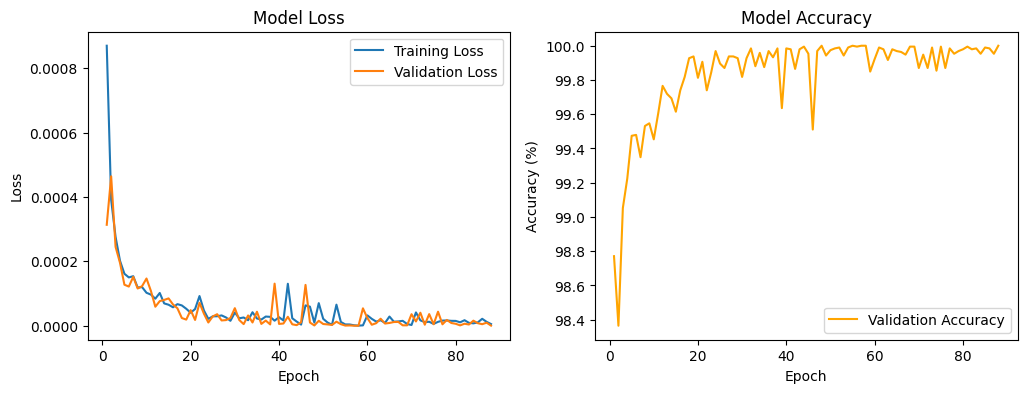

In [ ]:
#@title <h2>Part 5: Plotting Training History</h2>
#@markdown <p>We can now plot the model's accuracy and loss over the epochs. This helps us see if the model is still improving or if it has started to "overfit."</p>

plt.figure(figsize=(12, 4))

# Plot training and validation loss
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, label='Validation Accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.show()

In [ ]:
#@title <h2>Part 6: Evaluation on test set</h2>

# Evaluate the best model on the test set
print("\nEvaluating the best model on the test set:")
test(model, device, test_loader)


Evaluating the best model on the test set:


Testing:   0%|          | 0/79 [00:00<?, ?it/s]


Test set: Average loss: 0.0003, Accuracy: 9948/10000 (99.48%)



(0.0002884972068509805, 99.48)

## Conclusion

In this section, we implemented several best practices for training a neural network:

1.  **Train-Validation-Test Split:** We split the original training data into separate training and validation sets. This allows us to monitor the model's performance on unseen data during training and helps detect overfitting. The test set is kept completely separate and is only used for the final evaluation of the best model.
2.  **Early Stopping:** We implemented an early stopping mechanism that monitors the validation loss. If the validation loss does not improve for a specified number of epochs (`patience`), training is stopped early. This prevents the model from overfitting to the training data and saves computational resources.
3.  **Saving the Best Model:** We saved the model's state dictionary whenever a new best validation loss was achieved. After training (either completed or stopped early), we loaded the state dictionary of the model that performed best on the validation set. This ensures that we use the model with the best generalization performance for the final evaluation.
4.  **Using Pre-trained Weights:** Although not explicitly modified in this step, we continued to use the ResNet34 model initialized with pre-trained ImageNet weights. This transfer learning approach leverages features learned from a large dataset, which can significantly improve performance and reduce the amount of data and training time required for a new task, even if the tasks are different (like ImageNet classification and MNIST digit recognition).

By incorporating these practices, we have built a more robust and efficient training pipeline. The final evaluation on the test set using the best model provides a more reliable estimate of how the model will perform on truly unseen data.

# Section 4: Industrial exemple on Safran-MNIST-DLS dataset and DAGECC Competition

## Dataset Overview

The **SAFRAN-MNIST-DLS** dataset is an industrial variant of the classic MNIST dataset, developed within the framework of the **DAGECC Challenge** (Data Analysis and Generalization for Embedded Character Classification).  
It was released in collaboration with **SAFRAN Electronics & Defense**, aiming to benchmark **OCR algorithms under realistic industrial conditions**.

Unlike the original MNIST dataset—which contains clean, centered, handwritten digits—**SAFRAN-MNIST-DLS** introduces several layers of complexity that mimic real industrial data:

| Aspect | MNIST | SAFRAN-MNIST-DLS |
|--------|--------|------------------|
| **Image Source** | Handwritten digits (NIST) | Printed and engraved digits from industrial components |
| **Noise** | Minimal | Variable lighting, blur, reflections, surface textures |
| **Alignment** | Centered | Off-centered, rotated, and partially occluded |
| **Grayscale Range** | Normalized | Broader contrast variations due to material differences |
| **Labels** | 0–9 handwritten digits | 0–9 industrially printed or engraved digits |
| **Resolution** | 28×28 px | 32×32 px (resized / cropped for training) |

### Purpose
This dataset is designed to evaluate a model’s **robustness** and **generalization** capacity when facing:
- Non-uniform backgrounds  
- Lighting inconsistencies  
- Industrial imaging conditions (metallic glare, engraved text)  

## The DAGECC Challenge

The DAGECC (Domain Adaptation & Generalization for Character Classification) competition, held as part of ICPR 2024, challenges participants to develop models that can recognize digits, letters, and symbols in industrial settings under domain shifts. It uses the Safran‑MNIST‑D and Safran‑MNIST‑DLS datasets, which contain images of characters on avionic parts with variations in lighting, texture, and surface, making generalization and adaptation non-trivial. The competition has two tracks: Domain Generalization, where models are trained only on source domains and tested on unseen target domains, and Unsupervised Domain Adaptation, where models can leverage unlabeled target domain data to improve performance. Evaluation is based on the macro-average F1-score, emphasizing balanced performance across all classes. This competition is highly relevant for industrial applications requiring robust character recognition and provides a realistic benchmark for research in domain adaptation and generalization.


## Task

In this section, we tackle the core tasks of the DAGECC competition using the **Safran‑MNIST‑DLS dataset**. We will:  
<ul>
  <li> Download and explore the dataset.  
  <li> Create a PyTorch **dataloader**.  
  <li> Visualize sample images.  
  <li> Train a simple supervised model (for illustration).  
  <li> Discuss strategies for the actual competition, where the **train set is unlabeled**.
</ul>

The dataset is available on Zenodo: [https://zenodo.org/records/13321202](https://zenodo.org/records/13321202). You can download it manually or using `wget`:

```bash
!wget -O Safran-MNIST-DLS.zip https://zenodo.org/record/13321202/files/Safran-MNIST-DLS.zip?download=1
!unzip Safran-MNIST-DLS.zip -d ./data/


# References

1. **Deng, L. (2012).** The MNIST database of handwritten digit images for machine learning research. *IEEE Signal Processing Magazine, 29*(6), 141–142.

2. **LeCun, Y., Cortes, C., & Burges, C. J. C. (1998).** THE MNIST DATABASE of handwritten digits. Online: [http://yann.lecun.com/exdb/mnist/](http://yann.lecun.com/exdb/mnist/)

3. **Marino, S., Vandoni, J., Aldea, E., Lemghari, I., Le Hégarat-Mascle, S., & Jurie, F. (2024).** Safran‑MNIST‑DLS: Images of serial numbers from avionic parts (industrial character classification) – Dataset on Zenodo. Online: [https://zenodo.org/records/13321202](https://zenodo.org/records/13321202)

4. **Marino, S., Vandoni, J., Aldea, E., Lemghari, I., Le Hégarat-Mascle, S., & Jurie, F. (2024).** ICPR 2024 Competition on Domain Adaptation and Generalization for Character Classification (DAGECC). In *Pattern Recognition. Competitions – Proceedings of the 2024 International Conference on Pattern Recognition*. DOI: [10.1007/978-3-031-80139-6_12](https://doi.org/10.1007/978-3-031-80139-6_12)

5. **He, K., Zhang, X., Ren, S., & Sun, J. (2016).** Deep Residual Learning for Image Recognition. In *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR)* (pp. 770–778). arXiv: [1512.03385](https://arxiv.org/abs/1512.03385)
